In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_data = pd.read_csv("../raw_data/nfl_odds_2007-2022.csv", parse_dates=["date"])
raw_data.shape

(4025, 12)

In [2]:
raw_data.head()

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,open_spread,close_spread,open_total,close_total,season
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,5.5,5.5,50.5,52.5,2007-08
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,38.5,37.5,2007-08
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,3.0,37.0,38.5,2007-08
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,4.5,5.0,37.5,36.0,2007-08
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,6.5,7.5,37.5,39.5,2007-08


### Away ML

In [4]:
raw_data['away_ml'].describe()

count    4025.000000
mean       74.409441
std       303.669518
min     -2500.000000
25%      -150.000000
50%       140.000000
75%       240.000000
max      2173.000000
Name: away_ml, dtype: float64

In [8]:
#outliers
q1_aml, q3_aml =  raw_data['away_ml'].quantile([.25, .75])
iqr_aml = q3_aml - q1_aml
lower_aml, upper_aml = q1_aml - 1.5 * iqr_aml, q3_aml + 1.5 * iqr_aml
outliers_aml = raw_data[~raw_data['away_ml'].between(lower_aml, upper_aml)]
outliers_aml['away_ml']


36      1350
68      1050
93     -1700
114     1000
145     1000
        ... 
3956    -800
3969    -750
3982   -1000
3988     900
4001   -1100
Name: away_ml, Length: 83, dtype: int64

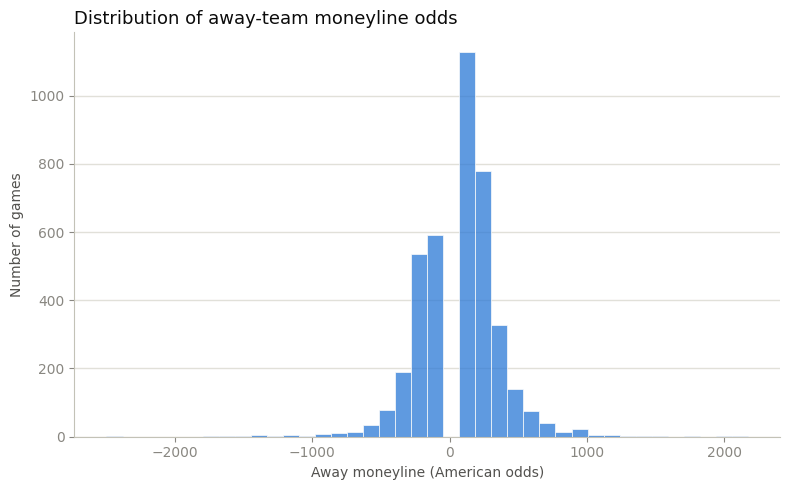

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="away_ml",
    bins=40,
    color="#2a78d6",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of away-team moneyline odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Away moneyline (American odds)", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Home ML Eda

In [7]:
raw_data['home_ml'].describe()

count    4025.000000
mean     -148.743354
std       378.210495
min     -5000.000000
25%      -295.000000
50%      -160.000000
75%       130.000000
max      1100.000000
Name: home_ml, dtype: float64

In [13]:
raw_data[raw_data['home_ml'] == -5000]

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,open_spread,close_spread,open_total,close_total,season
1689,2013-10-13,Jacksonville,Denver,19,35,2173,-5000,24.0,26.5,47.0,52.5,2013-14
3244,2019-09-22,Miami,Dallas,6,31,1500,-5000,17.0,22.5,47.0,46.5,2019-20
3582,2020-11-01,NYJets,KansasCity,9,35,1500,-5000,21.0,19.5,47.5,49.0,2020-21


The -5000 odds seem very unlikely but these made sense given the away_ml matching. -5000 seems to be a market cap on odds but even though they are extreme outliers they are real odds for very one-sided matchups so they will not be removed

In [9]:
#outliers
q1_hml, q3_hml = raw_data['home_ml'].quantile([.25, .75])
iqr_hml = q3_hml - q1_hml
lower_hml , upper_hml = q1_hml - 1.5 * iqr_hml , q3_hml + 1.5 * iqr_hml
outliers_hml = raw_data[~raw_data['home_ml'].between(lower_hml, upper_hml)]
outliers_hml['home_ml']

36     -2200
58     -1000
68     -1600
93      1100
114    -1500
        ... 
3852     800
3867     800
3983   -1000
3988   -1600
4002   -1400
Name: home_ml, Length: 111, dtype: int64

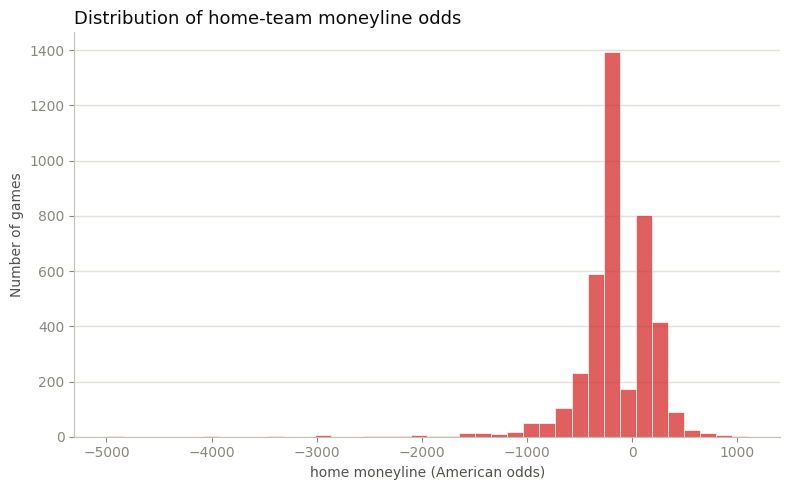

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="home_ml",
    bins=40,
    color="#d62a2a",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of home-team moneyline odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("home moneyline (American odds)", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Closed spread
* only care about closed spread because it is the market with all the information right before kickoff

In [3]:
raw_data.head()

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,open_spread,close_spread,open_total,close_total,season
0,2007-09-06,NewOrleans,Indianapolis,10,41,200,-240,5.5,5.5,50.5,52.5,2007-08
1,2007-09-09,KansasCity,HoustonTexans,3,20,170,-200,0.0,3.0,38.5,37.5,2007-08
2,2007-09-09,Denver,Buffalo,15,14,-170,150,3.0,3.0,37.0,38.5,2007-08
3,2007-09-09,Pittsburgh,Cleveland,34,7,-235,195,4.5,5.0,37.5,36.0,2007-08
4,2007-09-09,Tennessee,Jacksonville,13,10,290,-350,6.5,7.5,37.5,39.5,2007-08


In [4]:
raw_data['close_spread'].describe()

count    4025.000000
mean        5.473665
std         3.612547
min        -6.000000
25%         3.000000
50%         4.500000
75%         7.000000
max        26.500000
Name: close_spread, dtype: float64

In [7]:
q1_spread, q3_spread = raw_data['close_spread'].quantile([.25,.75])
iqr_spread = q3_spread - q1_spread
lower_spread, upper_spread = q1_spread - 1.5 * iqr_spread, q3_spread + 1.5 * iqr_spread
outliers_spread = raw_data[~raw_data['close_spread'].between(lower_spread, upper_spread)]
outliers_spread['close_spread']

36      16.5
68      15.5
93      15.5
114     15.0
145     14.5
        ... 
3991    14.0
3994    13.5
4001    14.5
4002    16.0
4023    -3.5
Name: close_spread, Length: 188, dtype: float64

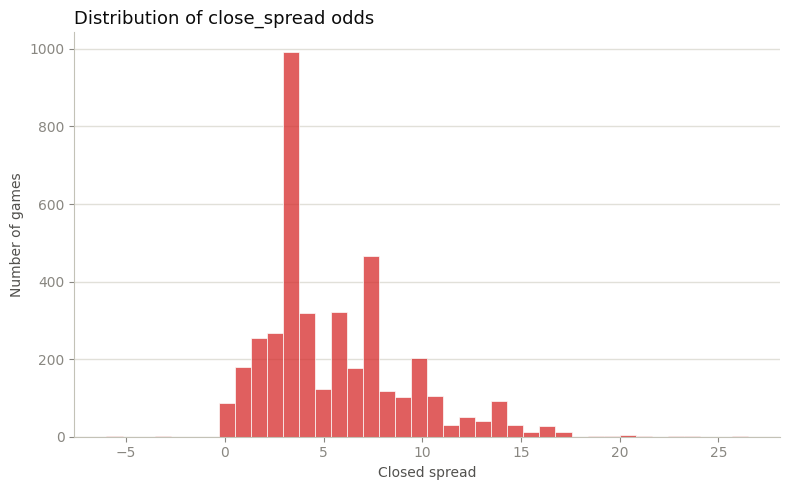

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="close_spread",
    bins=40,
    color="#d62a2a",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of close_spread odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Closed spread", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Closed total

In [ ]:
q1_total , q3_total = raw_data['close_total'].quantile([.25, .75])
iqr_total = q3_total - q1_total
lower_total , upper_total = q1_total - 1.5 * iqr_total , q3_total + 1.5 * iqr_total
outliers_total = raw_data[~raw_data['close_total'].between(lower_total, upper_total)]
outliers_total['close_total']

227    31.5
231    31.5
496    31.0
Name: close_total, dtype: float64

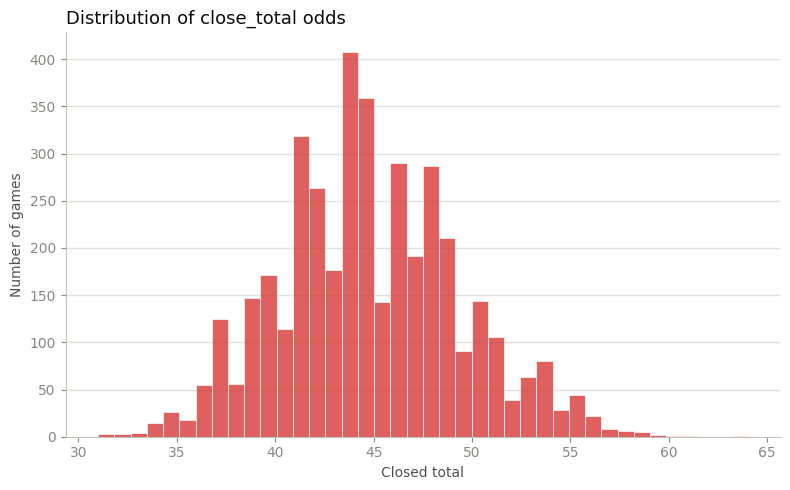

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="close_total",
    bins=40,
    color="#d62a2a",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of close_total odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Closed total", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Correlation heatmap

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cols = ["away_score", "home_score", "away_ml", "home_ml", "close_spread", "close_total"]
labels = ["Away score", "Home score", "Away ML", "Home ML", "Close spread", "Close total"]

corr = raw_data[cols].corr()
corr.index = labels
corr.columns = labels

# diverging: blue -> -1, dark red -> +1, neutral gray at 0
cmap = LinearSegmentedColormap.from_list("diverging_blue_red", ["#2a78d6", "#f0efec", "#c21f1e"])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
hm = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0, cmap=cmap,
    annot=True, fmt=".2f", annot_kws={"fontsize": 10},
    square=True, linewidths=2, linecolor="#fcfcfb",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)

# text should never fight the fill color -- flip to white on saturated cells
for text, value in zip(hm.texts, corr.values.flatten()):
    text.set_color("#ffffff" if abs(value) > 0.5 else "#0b0b0b")

fig.suptitle(
    "Correlation between score, moneyline, and closing-line fields",
    x=0.02, ha="left", fontsize=12.5, color="#0b0b0b", y=0.98,
)
ax.tick_params(colors="#52514e", length=0)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(colors="#898781")
cbar.set_label("Pearson correlation", color="#52514e")
cbar.outline.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()